# Simple Chatbpt

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,CharacterTextSplitter
from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma,FAISS
import fitz  

#utility
import numpy as np
from typing import List,Dict,Any
from sentence_transformers import SentenceTransformer

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.runnables import (RunnablePassthrough,RunnableMap)
from langchain_core.output_parsers import StrOutputParser
import os
import numpy as np
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document

from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_classic.document_loaders import WikipediaLoader
from PIL import Image
import torch
from transformers import CLIPProcessor,CLIPModel
import base64
import io
from langchain.messages import SystemMessage,HumanMessage,AIMessage
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage,SystemMessage
from langchain.tools import tool
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages


C:\Users\kanha\AppData\Local\Temp\ipykernel_18492\1012247832.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader,PyMuPDFLoader


In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages


In [4]:
class State(TypedDict):
    messages:Annotated[list,add_messages]


In [7]:
## Step 4: LLM and prompt
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GROQ_API_KEY"] =os.getenv("OPENAI_API_KEY")
llm=init_chat_model(model="groq:llama-3.3-70b-versatile")
response=llm.invoke("Why do parrots talk?")
response

AIMessage(content='Parrots are known for their remarkable ability to mimic human speech and other sounds, but why do they do it? The answer lies in their evolution, social behavior, and communication needs.\n\n**Evolutionary advantages:**\n\n1. **Mimicry as a survival strategy:** In the wild, parrots use vocal mimicry to blend in with their surroundings, warn predators, or attract prey. By mimicking other birds, animals, or even mechanical sounds, they can create a "deceptive" appearance, making it harder for predators to identify them.\n2. **Territorial defense:** Parrots use vocalizations, including mimicry, to defend their territory and warn other birds to stay away. By mimicking other birds or sounds, they can create the illusion of a larger, more formidable presence.\n\n**Social behavior:**\n\n1. **Communication and bonding:** Parrots are social birds that live in flocks in the wild. They use vocalizations, including mimicry, to communicate with each other, strengthen social bonds

In [8]:
#Nodes
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}


In [10]:
from IPython.display import Image,display


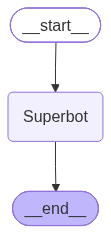

In [11]:
graph=StateGraph(State)
graph.add_node("Superbot",superbot)
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)
graph_builder=graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [12]:
graph_builder.invoke({'messages':"Hi My Name is saksham i Like cricket"})


{'messages': [HumanMessage(content='Hi My Name is saksham i Like cricket', additional_kwargs={}, response_metadata={}, id='d3af1a65-2241-45ba-948d-97ecaef48265'),
  AIMessage(content="Nice to meet you, Saksham! Cricket is an exciting sport, and I'm sure you must be enjoying watching and playing it. Who's your favorite cricket team or player? Do you have a favorite format of the game, such as Test matches, ODIs, or T20s? Let's chat about cricket!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 45, 'total_tokens': 112, 'completion_time': 0.192693304, 'completion_tokens_details': None, 'prompt_time': 0.003689671, 'prompt_tokens_details': None, 'queue_time': 0.053346058, 'total_time': 0.196382975}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fa8c8-ebeb-7532-b73b-58cbcd2847cb-0', tool_calls=

## Streaming response

In [15]:
for event in graph_builder.stream({"messages":"Hello My name is saksham"},stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello My name is saksham', additional_kwargs={}, response_metadata={}, id='7595647b-3ef1-4d8f-b18f-32118d3da9f3')]}
{'messages': [HumanMessage(content='Hello My name is saksham', additional_kwargs={}, response_metadata={}, id='7595647b-3ef1-4d8f-b18f-32118d3da9f3'), AIMessage(content="Hello Saksham! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 42, 'total_tokens': 70, 'completion_time': 0.040901833, 'completion_tokens_details': None, 'prompt_time': 0.003684023, 'prompt_tokens_details': None, 'queue_time': 0.186568125, 'total_time': 0.044585856}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fa8cb-3046-7572-ba88-370065737e61-0', tool_calls=[], invalid_tool_calls=[]